<a href="https://colab.research.google.com/github/adityaprasad2005/ES335-assignment_2/blob/main/Task4_1_matrix_factorization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Preview example:** Movie Recommendation using matrix factorization

In [34]:
#import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# getting the excel data
movie_data = pd.read_excel(r"/content/Movie Recommendation 2024 (Responses).xlsx")

movie_data.drop(['Timestamp'], axis= 1, inplace=True)
movie_data.set_index('Your name', inplace=True)
movie_data.head(10)

# mask = movie_data== np.NaN
# get movie data for a user
user = "Daksh Jain"
user_idx = movie_data.index.get_loc(user)
print(user in movie_data.index)
user_ratings = movie_data.loc[user]
user_ratings



True


,Daksh Jain
Sholay,5.0
Swades (We The People),NaN
The Matrix (I),5.0
Interstellar,5.0
Dangal,4.0
Taare Zameen Par,4.0
Shawshank Redemption,5.0
The Dark Knight,5.0
Notting Hill,NaN
Uri: The Surgical Strike,4.0


In [35]:
# Number of missing values
movie_data.isnull().sum(axis = 0)

,0
Sholay,19
Swades (We The People),53
The Matrix (I),23
Interstellar,15
Dangal,1
Taare Zameen Par,1
Shawshank Redemption,54
The Dark Knight,36
Notting Hill,73
Uri: The Surgical Strike,13


In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Set device to cuda:0 if available and on Linux
# If on mac try mps
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Working on device: ", device)

def factorize_matrix(A, r, device= torch.device("cpu")):
  """
  Inputs
  A: ratings matrix of shape(n_user, n_movies)
  r: number of latent features

  Outputs
  W: matrix of shape(n_user, r)
  H: matrix of shape(r, n_movies)
  loss: loss value
  """
  n_user, n_movies = A.shape

  A = A.to(device)
  W = torch.randn(n_user, r, requires_grad= True, device = device)
  H = torch.randn(r, n_movies, requires_grad= True, device = device)

  optimizer = optim.Adam([W,H], lr= 0.01)

  mask = ~torch.isnan(A)

  for i in range(1000):
    diff_matrix = A - torch.mm(W, H)
    diff_matrix = diff_matrix[mask]

    loss = torch.norm(diff_matrix)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  return W, H, loss


Working on device:  cpu


In [37]:
torch_movie_data = torch.tensor(movie_data.values, dtype = torch.float)

for k in range(3, 15):
  W, H, loss = factorize_matrix(torch_movie_data, k, device)
  print(f"r: {k}  loss: {loss}")

r: 3  loss: 19.414297103881836
r: 4  loss: 16.3718318939209
r: 5  loss: 14.481005668640137
r: 6  loss: 11.541009902954102
r: 7  loss: 8.366732597351074
r: 8  loss: 5.703616619110107
r: 9  loss: 3.973613977432251
r: 10  loss: 0.28142228722572327
r: 11  loss: 0.29897502064704895
r: 12  loss: 0.18120107054710388
r: 13  loss: 0.3116699159145355
r: 14  loss: 0.17933505773544312


In [39]:
# compare the original and the reconstructed dataset
print("Original Ratings: \n",movie_data.loc[user], "\n")
print("Reconstructed Ratings: \n", torch.mm(W, H)[user_idx])


Original Ratings: 
 Sholay                      5.0
Swades (We The People)      NaN
The Matrix (I)              5.0
Interstellar                5.0
Dangal                      4.0
Taare Zameen Par            4.0
Shawshank Redemption        5.0
The Dark Knight             5.0
Notting Hill                NaN
Uri: The Surgical Strike    4.0
Name: Daksh Jain, dtype: float64 

Reconstructed Ratings: 
 tensor([5.0014, 4.3634, 5.0024, 5.0022, 3.9998, 4.0003, 5.0011, 4.9998, 5.5665,
        3.9994], grad_fn=<SelectBackward0>)


**Task 4.1** Pick an image of your liking and reconstruct it using matrix factorization. Choose a suitable value for the rank r. Run Gradient Descent until it converges, plot the reconstructed image alongside the original image. Calculate and report the RMSE and PSNR metrics.

In [40]:
# Download the image
import os
if os.path.exists('dog.jpg'):
    print('dog.jpg exists')
else:
    !wget https://segment-anything.com/assets/gallery/AdobeStock_94274587_welsh_corgi_pembroke_CD.jpg -O dog.jpg

--2025-03-12 08:57:43--  https://segment-anything.com/assets/gallery/AdobeStock_94274587_welsh_corgi_pembroke_CD.jpg
Resolving segment-anything.com (segment-anything.com)... 18.66.171.48, 18.66.171.20, 18.66.171.91, ...
Connecting to segment-anything.com (segment-anything.com)|18.66.171.48|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 221810 (217K) [image/jpeg]
Saving to: ‘dog.jpg’

dog.jpg             100%[===================>] 216.61K   496KB/s    in 0.4s    

2025-03-12 08:57:45 (496 KB/s) - ‘dog.jpg’ saved [221810/221810]



In [42]:
#Read the image using torchvision
import torchvision

image = torchvision.io.read_image('dog.jpg')
print(image.shape)

torch.Size([3, 1365, 2048])


In [43]:
#turn the image into grayscale
image = torch.tensor(image, dtype = torch.float)
image = image.mean(dim= 0, keepdim= False)
image.shape

<ipython-input-43-c31addf68774>:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype = torch.float)


torch.Size([1365, 2048])

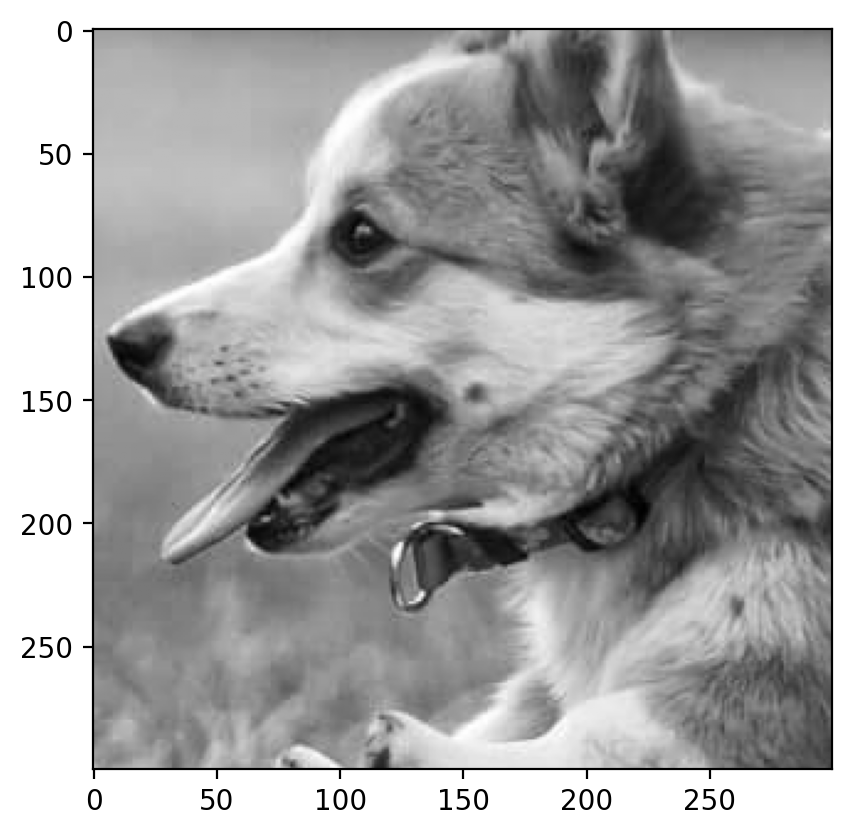

In [44]:
#crop this image
# plt.imshow(image, cmap= 'gray')
cropped_img = torchvision.transforms.functional.crop(image, 600, 800, 300, 300)
plt.imshow(cropped_img, cmap= 'gray')

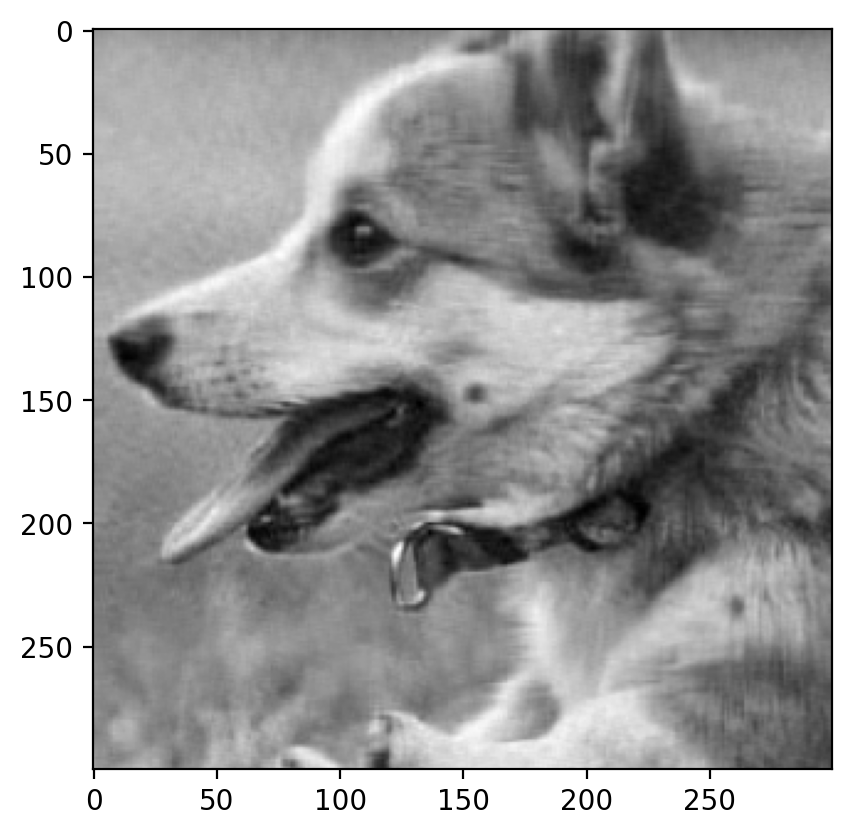

In [48]:
#factorize the image and show the reconstructed image
W, H, loss = factorize_matrix(cropped_img, 50, device)
reconstructed_img = torch.mm(W, H)
plt.imshow(reconstructed_img.cpu().detach().numpy(), cmap= 'gray')
print(f"r: 50 loss: {loss}")